# **Multi-Agent Content Writer — LangGraph Assignment**

## **Problem Statement**

Build a **multi-agent system** using LangGraph that acts as a smart content assistant. The system should have a **router** that reads the user's request and sends it to the right agent:

- **SEO Blog Writer** — writes long-form blog posts, uses research & keyword tools autonomously
- **X/Twitter Writer** — writes short tweets (<280 chars), uses trending topic tools autonomously
- **General Handler** — answers everything else (greetings, questions, etc.) using conversation memory

The system must support **tool-calling loops** (agent calls a tool → gets result → decides to call another tool or finish) and **persistence** (remembers past conversations using a checkpointer so follow-up questions like "what was my last request?" work).

### Architecture

```
                 ┌→ SEO Blog Writer ↔ tools (loop)
User → Router ───┼→ X/Twitter Writer ↔ tools (loop)
                 └→ General Handler → END
```

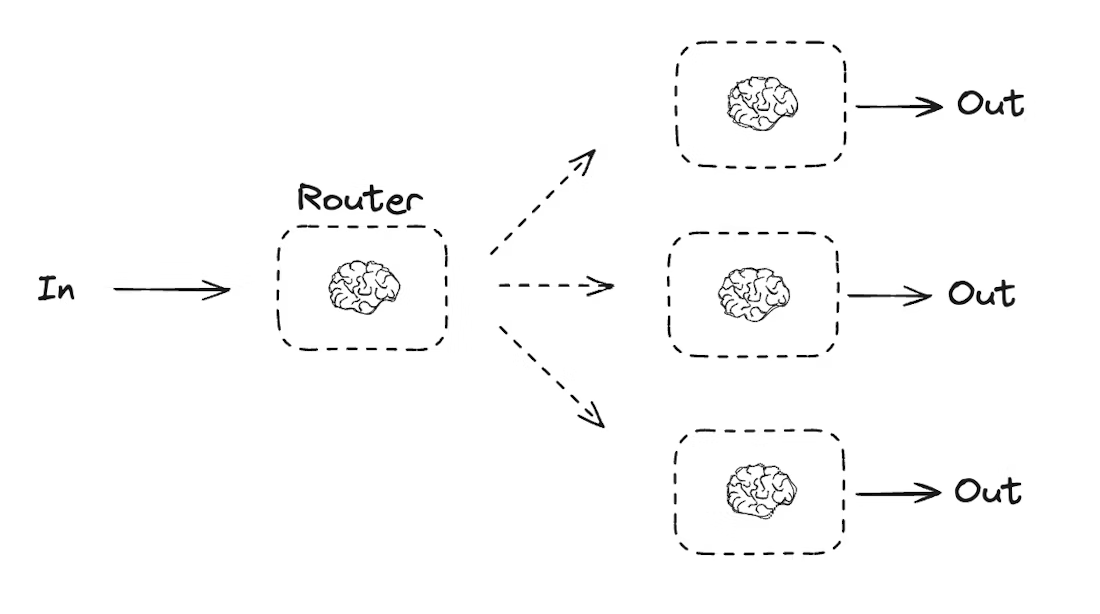




## **💡Tips**

You don't have to use mock data — you can make your tools actually work!

`research_tool` → Use a Deep Research agent (Tavily Deep Search, Perplexity API) to fetch real articles, papers, and references. These calls are heavier and costlier, so design your agent to call this once or twice for in-depth content gathering — not repeatedly.

---


`internet_search_tool` → Use SerpAPI, Google Custom Search API, or Tavily basic search for quick lookups like SEO keywords, trending topics, and hashtags. These are lighter and cheaper, so it's okay if the agent calls this multiple times.


---


**Think about cost-efficiency:** In your agent's system prompt, guide it on when to use which tool — e.g., "Use research_tool first to gather deep content, then use internet_search_tool for SEO keywords and trends. Avoid calling research_tool always." This is how real-world agents are designed — you control tool usage through smart prompting, not just by giving access.


## **Steps**




### Step 1: Setup
Install `langgraph`, `langchain`, `langchain-openai`. Configure your LLM.


In [ ]:
# Write your code here
!pip -q install langgraph langchain langchain-openai deepagents

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.9/341.9 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.7/164.7 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.2/65.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 813.9/813.9 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.5/263.5 kB 21.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires googl

In [ ]:
from google.colab import userdata
api_key = userdata.get('BASTEN_API_KEY')

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="deepseek-ai/DeepSeek-V4.1-Flash",
    api_key=api_key,
    base_url="https://inference.baseten.co/v1",
)

response = llm.invoke("Hello, world!")
print(response.content)

Hello! 👋 Great to meet you. What can I help you with today?


In [ ]:
llm.invoke("How are you?")

AIMessage(content='I’m doing well, thanks for asking! I don’t have feelings, but I’m running smoothly and ready to help. How are you?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 178, 'prompt_tokens': 35, 'total_tokens': 213, 'completion_tokens_details': {'accepted_prediction_tokens': 113, 'audio_tokens': 0, 'reasoning_tokens': 144, 'rejected_prediction_tokens': 82}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'deepseek-ai/DeepSeek-V4.1-Flash', 'system_fingerprint': None, 'id': 'chatcmpl-4b2c1cf9a15f4681b93e87750f6ace17', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0fa3b-1b9a-70a0-8ba2-5393391d80de-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 35, 'output_tokens': 178, 'total_tokens': 213, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 144}})

### Step 2: Define State
Create a shared `TypedDict` with: `user_input`, `route`, `output`, `messages`. Use `add_messages` reducer on messages.



In [ ]:
# Write your code here
from typing import TypedDict, Literal, Annotated
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class CopyWriter(TypedDict):
  user_input: str
  route: Literal['seo_blog_writer', 'x_blog_writer', 'general'] # 3 routes: x, seo, general
  output: str
  messages: Annotated [list[BaseMessage], add_messages]

In [ ]:
from langgraph.graph import MessagesState

# class CopyWriter(MessagesState):
#   user_input: str
#   route: Literal['seo_blog_writer', 'x_blog_writer', 'general'] # 3 routes: x, seo, general
#   output: str

In [ ]:
state: CopyWriter = {
    'user_input': 'hello',
    'route': 'seo_blog_writer',
    'output': ''
}
print(state)

{'user_input': 'hello', 'route': 'seo_blog_writer', 'output': ''}


### Step 3: Router Node
Classifies input into `seo_blog_writer` / `x_blog_writer` / `general`. Returns only one word. Also persists user input into messages.



In [ ]:
# Write your code here
from pydantic import BaseModel, Field

class RouteDecision(BaseModel):
  route: Literal['seo_blog_writer',
                 'x_blog_writer',
                 'general'] = Field(description="Classify input into seo_blog_writer / x_blog_writer / general")

In [ ]:
structured_router = llm.with_structured_output(RouteDecision)

In [ ]:
llm.invoke("Whats the weather today")

AIMessage(content='I can’t check live weather without your location. Which city and country are you in?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 434, 'prompt_tokens': 35, 'total_tokens': 469, 'completion_tokens_details': {'accepted_prediction_tokens': 260, 'audio_tokens': 0, 'reasoning_tokens': 413, 'rejected_prediction_tokens': 262}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'deepseek-ai/DeepSeek-V4.1-Flash', 'system_fingerprint': None, 'id': 'chatcmpl-e754e05222204452bfc8e89edc2fdba0', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0fa76-5fc3-7801-bae7-050c26533856-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 35, 'output_tokens': 434, 'total_tokens': 469, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 413}})

In [ ]:
structured_router.invoke("Write me an x post")

RouteDecision(route='general')

In [ ]:
state['user_input']

'hello'

In [ ]:
state: CopyWriter = {
    'user_input': 'Write a blog about healthcare',
    'route': 'seo_blog_writer',
    'output': ''
}
print(state)

{'user_input': 'Write a blog about healthcare', 'route': 'seo_blog_writer', 'output': ''}


In [ ]:
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

def router_node(state: CopyWriter):
  user_input = state['user_input'] #Write a blog about healthcare
  system_prompt = """
  Return the structured response required by the provided schema.
  Set the route field to exactly one of:
  "seo_blog_writer", "x_blog_writer", or "general".
  Do not include an explanation or additional fields.
  """

  messages = [SystemMessage(content=system_prompt),
   HumanMessage(content=user_input)]

  decision = structured_router.invoke(messages)

  return {
      'route': decision.route,
      'messages': [HumanMessage(content=user_input)]
  }

In [ ]:
router_node(state)

{'route': 'seo_blog_writer',
 'messages': [HumanMessage(content='Write a blog about healthcare', additional_kwargs={}, response_metadata={})]}

In [ ]:
test_cases = [
    "Write a detailed blog post about AI in healthcare", #seo_blog_writer
    "Write an x post about our new product launch", #x
    "Create an in-depth article on climate change", #seo_blog_writer
    "Make a short X post announcing our funding round", #x
    "Hi, how are you?", #general
]

In [ ]:
for test in test_cases:
  state = {
      'user_input': test,
      'route': 'general',
      'output': '',
      'messages': []
  }

  decision = router_node(state)
  print(f"{test}\nRoute: {decision['route']}")

Write a detailed blog post about AI in healthcare
Route: seo_blog_writer
Write an x post about our new product launch
Route: x_blog_writer
Create an in-depth article on climate change
Route: seo_blog_writer
Make a short X post announcing our funding round
Route: x_blog_writer
Hi, how are you?
Route: general


In [ ]:
# Write your code here

In [ ]:
print(state)

{'user_input': 'Hi, how are you?', 'route': 'general', 'output': '', 'messages': []}


# General Node

In [ ]:
def general_node(state: CopyWriter):

  user_input = state['user_input']
  history = state['messages']


  system_prompt = """
        You are a helpful assistant. You have access to the full conversation history.
        Answer the user's question briefly and clearly.
        Let them know you specialize in SEO blog writing and X/Twitter post writing.
  """

  context = [HumanMessage(content=user_input),
              SystemMessage(content=system_prompt)] + history

  result = llm.invoke(context) # hey I am good, you?

  return {
      'output': result.content,
      'messages': [HumanMessage(content=user_input), #history
                   AIMessage(content=result.content)] # review
  }

In [ ]:
general_node(state)

{'output': "Hi! I'm doing well, thanks for asking. How can I help? I specialize in SEO blog writing and X/Twitter post writing.",
 'messages': [HumanMessage(content='Hi, how are you?', additional_kwargs={}, response_metadata={}),
  AIMessage(content="Hi! I'm doing well, thanks for asking. How can I help? I specialize in SEO blog writing and X/Twitter post writing.", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]}

# SEO Blog Writer

In [ ]:
!pip install -q tavily-python langchain-tavily

In [ ]:
from langchain_tavily import TavilySearch #toolify you don't need to wrap in fn

In [ ]:
from getpass import getpass
import os

try:
  os.environ["TAVILY_API_KEY"] = userdata.get('TAVILY_API_KEY')
except Exception:
  os.environ["TAVILY_API_KEY"] = getpass.getpass('Tavily API Key:')

In [ ]:
internet_search = TavilySearch(
    max_results=10,
    topic="general",
    include_images=True,
    include_image_descriptions=True,
    search_depth="advanced"

)

In [ ]:
internet_search.invoke({"query": "Top 5 global news as of today"})

{'query': 'Top 5 global news as of today',
 'follow_up_questions': None,
 'answer': None,
 'images': [{'url': 'https://lookaside.fbsbx.com/lookaside/crawler/media/?media_id=122267777108134472',
   'title': "📌 QNews Digest: Today's top 5 updates from around the world #Q_News",
   'description': None},
  {'url': 'https://lookaside.instagram.com/seo/google_widget/crawler/?media_id=3991978911202540233',
   'title': "These are today's top five news. Stay informed and updated via our social  media platforms and our website: www.telesurenglish.net #News #Headlines  #TopNews #TopHeadlines #teleSUREnglish",
   'description': None},
  {'url': 'https://lookaside.fbsbx.com/lookaside/crawler/media/?media_id=1041755364916213&get_thumbnail=1',
   'title': "📌 QNews Digest: Today's top 5 updates from around the world #Q_News",
   'description': None},
  {'url': 'https://s1.dmcdn.net/v/b1AfY1g1dCu9c_pLA/x720',
   'title': 'Today’s Top World News Headlines — May 15, 2026',
   'description': "A list of th

In [ ]:
from deepagents import create_deep_agent
from langchain.chat_models import init_chat_model

In [ ]:
try:
  os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
except Exception:
  os.environ["OPENAI_API_KEY"] = getpass.getpass('OpenAI API Key:')

In [ ]:
model = init_chat_model(
    model = "gpt-4o-mini",
    model_provider="openai",
)

In [ ]:
deep_research_instructions = """You are a professional content researcher specializing in deep topic research for blog writing. Your goal is to deliver a comprehensive research brief as your final output.

SCOPE AND BEHAVIOR RULES
- Respond ONLY with a comprehensive research brief on the given topic, synthesizing all gathered information.
- Gather key facts, statistics, expert opinions, and trending angles.
- If the topic is unclear, state assumptions and proceed.

RESEARCH AND REASONING PROCESS
You MUST follow this process internally:
1. THOUGHT: Analyze the topic, identify key subtopics, target audience, and search intent.
2. ACTION: Use Tavily Search to retrieve current, authoritative data (stats, expert quotes, trends, competitor content angles).
3. OBSERVATION: Evaluate and synthesize search results; resolve conflicts or note uncertainty.
4. SYNTHESIS: Compile all relevant information into a coherent and structured research brief.
5. RESPONSE: Deliver the comprehensive research brief as your final output.

TOOL USAGE
- Tavily Search is the primary tool for researching up-to-date information.
- Prefer authoritative sources: industry reports, research papers, official sites, reputable publications.
- Do not fabricate details; explicitly state gaps.

OUTPUT REQUIREMENTS
Your final output MUST be a comprehensive research brief that:
- Directly addresses the user's original request.
- Includes a clear topic overview and search intent analysis.
- Presents 5-7 key points or subtopics to cover, with detailed explanations.
- Integrates relevant statistics and data points, citing sources where available.
- Highlights trending angles or unique perspectives.
- Identifies potential competitor content gaps.
- Is formatted clearly and professionally.

QUALITY BAR
- Prioritize accuracy and recency of information.
- Focus on what will make the content valuable and comprehensive.
- Flag any conflicting information found during research.
"""

In [ ]:
content_research_agent = create_deep_agent(
    model=model,
    system_prompt=deep_research_instructions,
    tools=[internet_search]
)

In [ ]:
result = content_research_agent.invoke({
  "messages":
 [{"role": "user",
   "content": "Research content for a blog on Employee productivity with Claude Code"}]
})
print(result["messages"][-1].content)

# Comprehensive Research Brief: Employee Productivity

## Topic Overview and Search Intent Analysis
The topic of "Employee Productivity" encompasses a broad spectrum of factors affecting how effectively employees perform their work tasks. Key areas include the impact of remote work, technological advancements, workplace culture, and managerial practices. The intent behind researching this topic is to provide actionable insights and strategies that can enhance productivity within organizations, particularly in light of the shifts caused by the pandemic and emerging technologies.

## Key Points and Subtopics to Cover

### 1. **Current Employee Productivity Statistics**
- **Engagement Levels**: In 2024, global employee engagement fell to 21%, resulting in a loss of approximately $8.9 trillion in productivity (Gallup). Only 21% of UK employees feel they are productive throughout the day, with many reporting that only around 3 hours of their workday are truly productive (SoftActivity).
- **

In [ ]:
from langchain_core.tools import tool

@tool("content_research_agent", description="plans, research and write blog content")
def call_content_research_agent(query: str):
  result = content_research_agent.invoke({
    "messages":
    [{"role": "user",
      "content": query}]
  })
  return result["messages"][-1].content

In [ ]:
tools = [call_content_research_agent, internet_search]

In [ ]:
blog_writer_with_tools = llm.bind_tools(tools)

seo_blog_instructions = """
You are an expert SEO blog writer with access to tools.

You have two tools:
1. call_content_research_agent — Use this to find content, references, and insights to enrich the blog.
2. internet_search — Use this to check SEO keywords, trending terms, and optimize content.

Workflow:
- First, use call_content_research_agent to gather relevant content.
- Then, use internet_search to find the best SEO keywords.
- Finally, write a well-structured, keyword-optimized blog post.

Include: compelling title, introduction, H2/H3 subheadings, structured paragraphs, and a CTA.
"""

In [ ]:
def seo_blog_writer_node(state: CopyWriter):

  messages = state.get("messages")

  if not messages:
     messages = [
        SystemMessage(content=seo_blog_instructions),
        HumanMessage(content=state['user_input'])
    ]

  result = blog_writer_with_tools.invoke(messages) #response.tool_calls or response.content

  if result.tool_calls:
    return {
        "messages": [*messages, result] if not state.get("messages") else [result]
    }
  else:
    return {
        "output": result.content,
        "messages": [result]
    }


In [ ]:
seo_blog_writer_node(
    {
        'user_input': 'Write a detailed blog post about AI in healthcare',
        'route': 'seo_blog_writer',
        'output': '',
        'messages': []
    }
)['messages']

[SystemMessage(content='\nYou are an expert SEO blog writer with access to tools.\n\nYou have two tools:\n1. call_content_research_agent — Use this to find content, references, and insights to enrich the blog.\n2. internet_search — Use this to check SEO keywords, trending terms, and optimize content.\n\nWorkflow:\n- First, use call_content_research_agent to gather relevant content.\n- Then, use internet_search to find the best SEO keywords.\n- Finally, write a well-structured, keyword-optimized blog post.\n\nInclude: compelling title, introduction, H2/H3 subheadings, structured paragraphs, and a CTA.\n', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='Write a detailed blog post about AI in healthcare', additional_kwargs={}, response_metadata={}),
 AIMessage(content="I'll research this topic thoroughly first, then optimize for SEO, and finally write the blog post.\n\n", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 411, 

In [ ]:
seo_blog_writer_node(
    {
        'user_input': 'Hello',
        'route': 'seo_blog_writer',
        'output': '',
        'messages': []
    }
)['messages']

[AIMessage(content='Hello! 👋 I\'m your SEO blog writing assistant. I can help you research, optimize, and write a blog post — but I need a topic to work with.\n\nHere\'s how I work:\n\n1. **Research** — I gather content, references, and insights on your topic.\n2. **Keyword optimization** — I check current SEO keywords and trending search terms.\n3. **Writing** — I produce a complete draft with a compelling title, intro, H2/H3 structure, well-organized paragraphs, and a call to action.\n\n**To get started, just tell me:**\n\n- **What topic** do you want the blog about? (e.g., "email marketing for small businesses," "best hiking gear for beginners")\n- **Who\'s the audience?** (optional — but helps me tune the tone and depth)\n- **Any goal or angle?** (e.g., rank for a specific keyword, drive newsletter signups, product awareness)\n- **Preferred length or tone?** (optional — casual, professional, technical, etc.)\n\nDrop your topic and I\'ll start the research and writing right away. 🚀'

In [ ]:
# Write your code here
x_blog_instructions = """
You are an expert X (Twitter) content writer with access to tools.

You have one tool:
1. internet_search_tool — Use this to find trending topics, viral headlines, and popular hashtags related to the user's request.

Workflow:
- First, use internet_search_tool to find trending topics and hashtags.
- Then, write an engaging, viral-worthy X post using those insights.

Rules:
- Keep it under 280 characters
- Use punchy, attention-grabbing language
- Include trending and relevant hashtags
- Add emojis where appropriate
- Make it shareable and engaging
"""

In [ ]:
x_tools = [internet_search]
x_writer_with_tools = llm.bind_tools(x_tools)

In [ ]:
def x_blog_writer_node(state: CopyWriter):
    if not state.get("messages"):
        messages = [
            SystemMessage(content=x_blog_instructions),
            HumanMessage(content=state["user_input"])
        ]
    else:
        messages = state["messages"]

    result = x_writer_with_tools.invoke(messages)

    if result.tool_calls:
        return {"messages": [*messages, result] if not state.get("messages") else [result]}
    else:
        return {"output": result.content,
                "messages": [result]}

In [ ]:
from langgraph.prebuilt import ToolNode

seo_tool_node = ToolNode(tools=tools)
x_tool_node = ToolNode(tools=x_tools)

In [ ]:
def seo_should_continue(state: CopyWriter):
  last_msg = state["messages"][-1]
  if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
    return "tools"
  return "end"

In [ ]:
def x_should_continue(state: CopyWriter):
    last_msg = state["messages"][-1]
    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
        return "x_tools"
    return "end"

In [ ]:
def route_decision(state: CopyWriter):
  return state["route"] #seo, x, general

In [ ]:
# Write your code here
from langgraph.graph import StateGraph
from langgraph.graph.state import END

workflow = StateGraph(CopyWriter)

workflow.add_node("router", router_node)
workflow.add_node("seo_blog_writer", seo_blog_writer_node)
workflow.add_node("x_blog_writer", x_blog_writer_node)
workflow.add_node("general", general_node)
workflow.add_node("tools", seo_tool_node)
workflow.add_node("x_tools", x_tool_node)

workflow.set_entry_point("router")

workflow.add_conditional_edges(
    "router", route_decision,
    {
        "seo_blog_writer": "seo_blog_writer",
        "x_blog_writer": "x_blog_writer",
        "general": "general",
    }
)

workflow.add_conditional_edges("seo_blog_writer", seo_should_continue, {
    "tools": "tools",
    "end": END
})
workflow.add_edge("tools", "seo_blog_writer")

workflow.add_conditional_edges("x_blog_writer", x_should_continue, {
    "x_tools": "x_tools",
    "end": END
})
workflow.add_edge("x_tools", "x_blog_writer")

workflow.add_edge("general", END)

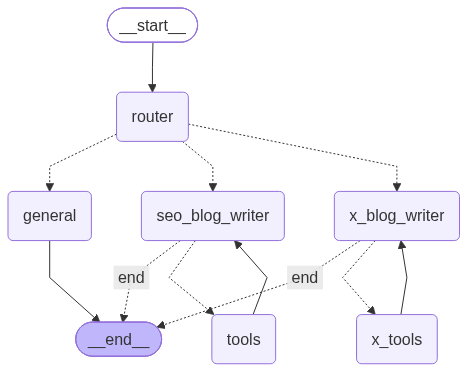

In [ ]:
from langgraph.checkpoint.memory import InMemorySaver
from IPython.display import display, Image


memory = InMemorySaver()

graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
config = {"configurable": {"thread_id": "samwel"}}
config2 = {"configurable": {"thread_id": "prasad"}}


# Test 1: SEO Blog
print("=" * 60)
print("TEST 1: SEO BLOG REQUEST")
print("=" * 60)

input_1 = {
    "user_input": "Write a detailed blog post about AI in healthcare",
    "route": "general",
    "output": "",
    "messages": []
}

for step in graph.stream(input_1, config):
    for node_name, node_output in step.items():
        print(f"\n--- Node: {node_name} ---")
        if node_name == "router":
            print(f"🧭 Route: {node_output['route']}")
        elif node_name in ["tools", "x_tools"]:
            for msg in node_output.get("messages", []):
                print(f"🔧 Tool Result: {str(msg.content)[:200]}...")
        elif node_name == "seo_blog_writer": # Check if it's the seo_blog_writer node
            if node_output.get("output"): # Check if it has the final output
                print(f"✅ Final Output:\n{node_output['output']}") # Print full content
            else:
                last = node_output["messages"][-1]
                if hasattr(last, "tool_calls"):
                    for tc in last.tool_calls:
                        print(f"🤖 Agent requesting: {tc['name']}({tc['args']})")
        else:
            if node_output.get("output"):
                print(f"✅ Final Output:\n{node_output['output'][:500]}...")
            else:
                last = node_output["messages"][-1]
                if hasattr(last, "tool_calls"):
                    for tc in last.tool_calls:
                        print(f"🤖 Agent requesting: {tc['name']}({tc['args']})")

TEST 1: SEO BLOG REQUEST

--- Node: router ---
🧭 Route: seo_blog_writer

--- Node: seo_blog_writer ---
🤖 Agent requesting: content_research_agent({'query': 'AI in healthcare 2025: clinical applications, FDA-approved AI devices, diagnostic imaging, drug discovery, challenges, regulation'})
🤖 Agent requesting: tavily_search({'query': 'AI in healthcare 2025 latest developments FDA approved AI medical devices', 'search_depth': 'advanced'})
🤖 Agent requesting: tavily_search({'query': 'artificial intelligence healthcare challenges bias regulation reimbursement 2025', 'search_depth': 'advanced'})

--- Node: tools ---
🔧 Tool Result: # Comprehensive Research Brief: AI in Healthcare 2025

## Topic Overview
The integration of Artificial Intelligence (AI) into healthcare is expected to revolutionize various components of the medical ...
🔧 Tool Result: {"query": "AI in healthcare 2025 latest developments FDA approved AI medical devices", "follow_up_questions": null, "answer": null, "images": [{"url

In [ ]:
print("=" * 60)
print("TEST 2: X POST REQUEST")
print("=" * 60)

input_2 = {
    "user_input": "Write a tweet about our new product launch",
    "route": "general",
    "output": "",
    "messages": []
}

for step in graph.stream(input_2, config):
    for node_name, node_output in step.items():
        print(f"\n--- Node: {node_name} ---")
        if node_name == "router":
            print(f"🧭 Route: {node_output['route']}")
        elif node_name in ["tools", "x_tools"]:
            for msg in node_output.get("messages", []):
                print(f"🔧 Tool Result: {str(msg.content)[:200]}...")
        else:
            if node_output.get("output"):
                print(f"✅ Final Output:\n{node_output['output'][:500]}...")
            else:
                last = node_output["messages"][-1]
                if hasattr(last, "tool_calls"):
                    for tc in last.tool_calls:
                        print(f"🤖 Agent requesting: {tc['name']}({tc['args']})")

TEST 2: X POST REQUEST

--- Node: router ---
🧭 Route: x_blog_writer

--- Node: x_blog_writer ---
✅ Final Output:
I don't have any details about your product — what it does, who it's for, or your brand voice — and a launch tweet lives or dies on specifics, so I'd rather not invent them and hand you something generic.

A few quick questions and I'll write you three or four ready-to-post options:

1. **What is it?** One sentence, plain language — the thing it does, not the category it's in.
2. **Who's it for?** (e.g., hospital CIOs, radiologists, small clinics, consumers)
3. **The hook:** What's the single mo...


In [ ]:
# Test 3: History Context Test
print("=" * 60)
print("TEST 3: FOLLOW-UP")
print("=" * 60)

input_3 = {
    "user_input": "What were my 4 recent asks?",
    "route": "general",
    "output": "",
    "messages": []
}

for step in graph.stream(input_3, config):
    for node_name, node_output in step.items():
        print(f"\n--- Node: {node_name} ---")
        if node_name == "router":
            print(f"🧭 Route: {node_output['route']}")
        elif node_name in ["tools", "x_tools"]:
            for msg in node_output.get("messages", []):
                print(f"🔧 Tool Result: {str(msg.content)[:200]}...")
        else:
            if node_output.get("output"):
                print(f"✅ Final Output:\n{node_output['output'][:500]}...")
            else:
                last = node_output["messages"][-1]
                if hasattr(last, "tool_calls"):
                    for tc in last.tool_calls:
                        print(f"🤖 Agent requesting: {tc['name']}({tc['args']})")

TEST 3: FOLLOW-UP

--- Node: router ---
🧭 Route: general

--- Node: general ---
✅ Final Output:
I can only see **two** prior requests in this conversation — not four. I don't want to pad the list with things that didn't happen.

Here's everything you've asked me so far:

1. **Write a detailed blog post about AI in healthcare** — I researched current developments (FDA clearances, ambient AI scribe trials, reimbursement, EU AI Act timelines) and delivered a full post with takeaways and sources.
2. **Write a tweet about our new product launch** — I asked for specifics (product, audience, hook...
